# 40 · CANDLE_SAVI · bulk_RNA_seq · input and batch correction

Reads the four CSV files in `data/Goldbach-Mansky_compiled_RNA-Seq_GeneCounts_CANDLE_AND_SAVI_SUBSET_2026_09_22/`.
Writes `counts_raw.rds`, `counts_combatseq.rds`, `samples.rds` and `sample_key.rds` in
`data/run_artifacts/CANDLE_SAVI/`.

**The data.** Internal bulk RNA sequencing gene counts, one file per sequencing facility: BCM-HGSC,
NCI-FNL, NIAID-NCI and NIAMS. The data are not in this repository; only this notebook and its outputs are.

**Layout of each file.**
- line 1: a row number, `Gene_ID` (Ensembl gene identifier with version), `Gene_Name`, `Stat`, then one
  column per sample;
- lines 2 to 10: the sample information (Enrollment ID, Metadata Initials, Sample Source, Diagnosis,
  Treatment, Sequencing_Facility, Sequencing_Cohort, Gender, RNA sample collection date);
- line 11 on: one gene per line, `Stat` = `Raw_Count`, one count per sample.

**Personal information.** The initials line is dropped when the files are read. Enrollment IDs and
collection dates are never printed. Each sample gets a code (`S001` on) and each patient a code (`P001`
on); only the codes appear in outputs and figures. The key linking codes to sequencing columns and
enrollment IDs is saved in `data/run_artifacts/CANDLE_SAVI/`, which is not committed.

**Steps.**
1. Read the four files; check their layout, genes and counts.
2. Keep blood samples of AGS, CANDLE, SAVI and UAID; merge diagnosis spellings; remove libraries below 1 million
   counts.
3. Name genes by Ensembl identifier without version.
4. Batch: sequencing facility, and within NIAMS the sequencing cohort. Diagnosis against batch.
5. Principal component analysis (PCA) before correction.
6. ComBat-seq batch correction of the counts (Zhang Y, Parmigiani G, Johnson WE. ComBat-seq: batch effect
   adjustment for RNA-seq count data. *NAR Genom Bioinform* 2020;2:lqaa078), and PCA after correction.

The corrected counts are for display (heatmaps). The differential expression notebook uses the raw counts,
with batch in the design, as the DESeq2 authors advise (Love MI, Anders S, Kim V, Huber W. RNA-seq workflow:
gene-level exploratory analysis and differential expression. *F1000Research* 2015;4:1070).

## Read the four files

In [1]:
source("../src/paths.R")
DIR   <- "Goldbach-Mansky_compiled_RNA-Seq_GeneCounts_CANDLE_AND_SAVI_SUBSET_2026_09_22"
FILES <- c("BCM-HGSC.csv", "NCI-FNL.csv", "NIAID-NCI.csv", "NIAMS.csv")
read_one <- function(f) {
  x <- read.csv(raw(DIR, f), header = FALSE, colClasses = "character", check.names = FALSE)
  stopifnot(identical(unname(unlist(x[1, 2:4])), c("Gene_ID", "Gene_Name", "Stat")),
            all(x[11:nrow(x), 4] == "Raw_Count"))
  info <- t(x[2:10, 5:ncol(x)]); colnames(info) <- trimws(x[2:10, 4])
  info <- info[, colnames(info) != "Metadata Initials", drop = FALSE]
  counts <- as.matrix(x[11:nrow(x), 5:ncol(x)])
  list(column = unname(unlist(x[1, 5:ncol(x)])), info = info,
       gene_id = x[11:nrow(x), 2], gene_name = x[11:nrow(x), 3], counts = counts)
}
d <- setNames(lapply(FILES, read_one), FILES)
data.frame(file = FILES, samples = sapply(d, function(z) ncol(z$counts)), genes = sapply(d, function(z) nrow(z$counts)))

,file,samples,genes
,<chr>,<int>,<int>
BCM-HGSC.csv,BCM-HGSC.csv,11,57820
NCI-FNL.csv,NCI-FNL.csv,20,57820
NIAID-NCI.csv,NIAID-NCI.csv,15,57820
NIAMS.csv,NIAMS.csv,126,57820


**Explanation**
- `DIR` is the folder of the four files inside `data/`; `raw(DIR, f)` gives the path of file `f` (see
  notebook 00 for `raw()`).
- `read_one(f)` reads one file:
  - `read.csv(..., header = FALSE, colClasses = "character")` reads every cell as text, because the first 10
    lines hold words and the rest numbers.
  - `stopifnot()` stops the notebook unless line 1 names `Gene_ID`, `Gene_Name` and `Stat` in columns 2 to 4,
    and every gene line says `Raw_Count`.
  - `info` holds lines 2 to 10, one row per sample: `t()` turns the lines into columns, and `trimws()`
    removes spaces around the labels. The `Metadata Initials` column is removed at once.
  - `counts` holds lines 11 on, columns 5 on: one row per gene, one column per sample.
- `lapply(FILES, read_one)` reads the four files; `setNames()` names each result by its file.
- The table gives the numbers of samples and genes per file.

**Result.** 172 samples: BCM-HGSC 11, NCI-FNL 20, NIAID-NCI 15, NIAMS 126; 57,820 genes in each file.

**Check.** The four files list the same genes in the same order, and every count is a whole number of 0 or
more.

In [2]:
same_genes <- sapply(d, function(z) identical(z$gene_id, d[[1]]$gene_id))
counts <- do.call(cbind, lapply(d, `[[`, "counts"))
storage.mode(counts) <- "numeric"
c(files_with_the_same_genes = sum(same_genes), missing = sum(is.na(counts)),
  not_whole = sum(counts != round(counts), na.rm = TRUE), negative = sum(counts < 0, na.rm = TRUE))
stopifnot(all(same_genes), !anyNA(counts), all(counts == round(counts)), all(counts >= 0))

files_with_the_same_genes                   missing                 not_whole 
                        4                         0                         0 
                 negative 
                        0

**Explanation**
- `identical(z$gene_id, d[[1]]$gene_id)` is TRUE when a file lists exactly the genes of the first file, in the
  same order.
- `do.call(cbind, lapply(d, `[[`, "counts"))` takes the counts of each file and puts them side by side: one
  table, genes by samples. `storage.mode(counts) <- "numeric"` turns the text into numbers.
- The line counts the files that agree, the missing values, the values that are not whole numbers and the
  negative values; `stopifnot()` stops the notebook if any check fails.

**Result.** All four files list the same 57,820 genes in the same order; no count is missing, negative or a
fraction.

## Sample table

In [3]:
info <- do.call(rbind, lapply(names(d), function(f) data.frame(file = f, d[[f]]$info, check.names = FALSE)))
info$sample <- sprintf("S%03d", seq_len(nrow(info)))
info$patient <- sprintf("P%03d", match(info[["Enrollment ID"]], unique(info[["Enrollment ID"]])))
key <- data.frame(sample = info$sample, patient = info$patient, file = info$file,
                  column = unlist(lapply(d, `[[`, "column")), enrollment_id = info[["Enrollment ID"]])
colnames(counts) <- info$sample
table(file = info$file, source = info[["Sample Source"]])
table(diagnosis = info$Diagnosis, file = info$file)

               source
file            B cells Blood Neutrophils skin
  BCM-HGSC.csv        0    11           0    0
  NCI-FNL.csv         1    14           2    3
  NIAID-NCI.csv       0    15           0    0
  NIAMS.csv           0   126           0    0

                                   file
diagnosis                           BCM-HGSC.csv NCI-FNL.csv NIAID-NCI.csv
  AGS                                          2           0             0
  AGS-like                                     0           0             2
  CANDLE                                       5           8             0
  CANDLE-like                                  0           2             0
  SAVI                                         4           3             0
  UAID                                         0           7            13
  Undifferentiated Interferonopathy            0           0             0
  Undifferentiated interferonopathy            0           0             0
                                   file
diagnosis                           NIAMS.csv
  AGS                                      14
  AGS-like                                  0
  CANDLE                                   68
  CANDLE-like                               1
  SAVI         

**Explanation**
- `info` stacks the sample information of the four files, one row per sample, with the file each came from.
- `sample` gives each sample a code, `S001` to `S172`, in file order. `sprintf("S%03d", 7)` gives `"S007"`.
- `patient` gives each enrollment ID a code, `P001` on: `match()` finds the position of each ID among the
  distinct IDs, so every sample of one patient gets the same code, also across files.
- `key` links sample code, patient code, file, sequencing column and enrollment ID. It is saved, not printed.
- The counts table is now named by sample code.
- The two tables count samples by file and sample source, and by diagnosis and file, as written in the files.

**Result.** 166 samples are blood; NCI-FNL also has 3 skin, 1 B-cell and 2 neutrophil samples. NIAMS writes
undifferentiated interferonopathy in two spellings (24 and 5 samples).

## Keep blood samples of AGS, CANDLE, SAVI and UAID

In [4]:
info$diagnosis <- info$Diagnosis
info$diagnosis[info$diagnosis %in% c("Undifferentiated Interferonopathy", "Undifferentiated interferonopathy")] <- "UAID"
DX <- c("AGS", "CANDLE", "SAVI", "UAID")
blood <- info[["Sample Source"]] == "Blood"
keep_dx <- info$diagnosis %in% DX
table(blood = blood, diagnosis_kept = keep_dx)
info <- info[blood & keep_dx, ]; counts <- counts[, info$sample]
table(diagnosis = info$diagnosis)
c(patients = length(unique(info$patient)), patients_with_more_than_one_sample = sum(table(info$patient) > 1))

       diagnosis_kept
blood   FALSE TRUE
  FALSE     0    6
  TRUE      5  161

diagnosis
   AGS CANDLE   SAVI   UAID 
    16     75     21     49 

patients patients_with_more_than_one_sample 
                                78                                 20

**Explanation**
- `diagnosis` copies the diagnosis; the two spellings of undifferentiated interferonopathy in NIAMS are both
  written as UAID, the label used in NCI-FNL and NIAID-NCI.
- `DX` lists the four diagnoses analysed: AGS, CANDLE, SAVI and UAID.
- `blood` is TRUE for samples whose source is blood; `keep_dx` is TRUE for samples with one of the four
  diagnoses. The table crosses the two. Only samples with both are kept, in the sample table and the counts:
  the skin, B-cell and neutrophil samples, and the CANDLE-like and AGS-like samples, are removed.
- The last lines count the samples per diagnosis, the patients, and the patients with more than one sample.

**Result.** 161 samples are blood with one of the four diagnoses: CANDLE 75, UAID 49, SAVI 21, AGS 16. Removed:
6 samples that are not blood and 5 blood samples with CANDLE-like (3) or AGS-like (2). The 161 samples come
from 78 patients; 20 patients have more than one sample.

## Sample quality: library size

In [5]:
lib <- colSums(counts)
MIN_READS <- 1e6
data.frame(sample = names(sort(lib))[1:5], total_counts = sort(lib)[1:5], row.names = NULL)
c(samples = length(lib), median_total_counts = median(lib), below_minimum = sum(lib < MIN_READS))
info <- info[lib >= MIN_READS, ]; counts <- counts[, info$sample]

sample,total_counts
<chr>,<dbl>
S127,540
S094,2322722
S096,2463888
S116,3663785
S139,3998880


samples median_total_counts       below_minimum 
                161            32790694                   1

**Explanation**
- `lib` holds each sample's total count (library size); the table shows the five smallest.
- `MIN_READS` is the minimum library size kept: 1 million counts. A library far below the others cannot be
  normalized with the rest and is removed before analysis (Conesa A, Madrigal P, Tarazona S, et al. A survey of
  best practices for RNA-seq data analysis. *Genome Biol* 2016;17:13).
- Samples below the minimum are removed from the sample table and the counts.

**Result.** One sample is below the minimum: S127 (NIAMS-Batch1, SAVI), with 540 counts in total; the median sample
has 32.8 million and the next smallest 2.3 million. Only 407 of S127's genes have any count, so the library is
taken as failed and removed. 160 samples remain: CANDLE 75, UAID 49, SAVI 20, AGS 16; 78 patients, 20 of them
with more than one sample.

## Name the genes

In [6]:
ens <- sub("\\.[0-9]+$", "", d[[1]]$gene_id)
par_y <- startsWith(ens, "ENSGR")
c(genes = length(ens), ENSGR_rows = sum(par_y), ENSGR_rows_with_counts = sum(rowSums(counts[par_y, , drop = FALSE]) > 0),
  repeated_ids = sum(duplicated(ens)))
rownames(counts) <- ens
genes <- data.frame(gene_id = ens, gene_name = d[[1]]$gene_name, row.names = ens)
keep <- !par_y | rowSums(counts) > 0
counts <- counts[keep, ]; genes <- genes[keep, ]
dim(counts)

genes             ENSGR_rows ENSGR_rows_with_counts 
                 57820                     47                     16 
          repeated_ids 
                     0

[1] 57789   160

**Explanation**
- `sub("\\.[0-9]+$", "", ...)` removes the version from each Ensembl identifier: `ENSG00000000003.10` gives
  `ENSG00000000003`. The version marks a revision of the gene model; the identifier names the gene.
- `ENSGR` identifiers are the copies of genes in the pseudoautosomal regions, the stretches shared by the X
  and Y chromosomes. The line counts them, those with any counts, and identifiers that occur twice.
- `genes` keeps each gene's identifier and name.
- `keep` drops the `ENSGR` rows that have no counts in any sample.

**Result.** 47 of the 57,820 identifiers are `ENSGR` rows; 16 of them have counts in these samples. No
identifier occurs twice after the version is removed. Dropping the 31 empty `ENSGR` rows leaves 57,789 genes.

## Batch

In [7]:
info$batch <- ifelse(info$Sequencing_Facility == "NIAMS",
                     paste0("NIAMS-", ifelse(info$Sequencing_Cohort %in% c("", "NA", "-"), "unlabelled", info$Sequencing_Cohort)),
                     info$Sequencing_Facility)
table(batch = info$batch, file = info$file)
table(batch = info$batch, diagnosis = info$diagnosis)

                  file
batch              BCM-HGSC.csv NCI-FNL.csv NIAID-NCI.csv NIAMS.csv
  BMC-HGSC                   11           0             0         0
  NCI-FNL                     0          12             0         0
  NIAID-NCI                   0           0            13         0
  NIAMS-Batch1                0           0             0        87
  NIAMS-Batch2                0           0             0        21
  NIAMS-unlabelled            0           0             0        16

                  diagnosis
batch              AGS CANDLE SAVI UAID
  BMC-HGSC           2      5    4    0
  NCI-FNL            0      2    3    7
  NIAID-NCI          0      0    0   13
  NIAMS-Batch1       8     53   11   15
  NIAMS-Batch2       0      7    1   13
  NIAMS-unlabelled   6      8    1    1

**Explanation**
- `batch` is the sequencing facility; for NIAMS it is the facility and the sequencing cohort (Batch1,
  Batch2, or unlabelled where the cohort is empty). `ifelse(test, yes, no)` chooses between two values for
  every sample.
- The first table checks each batch against its file. The facility is written `BMC-HGSC` in the file
  `BCM-HGSC.csv`; it is kept as written.
- The second table crosses batch with diagnosis. Batch correction can separate batch from diagnosis only
  where a diagnosis appears in more than one batch.

**Result.** Six batches: BMC-HGSC 11, NCI-FNL 12, NIAID-NCI 13, NIAMS-Batch1 87, NIAMS-Batch2 21 and
NIAMS-unlabelled 16. CANDLE, SAVI and UAID each appear in five batches and AGS in three; NIAID-NCI holds only
UAID samples.

## PCA before correction

genes expressed 
    57789     26636

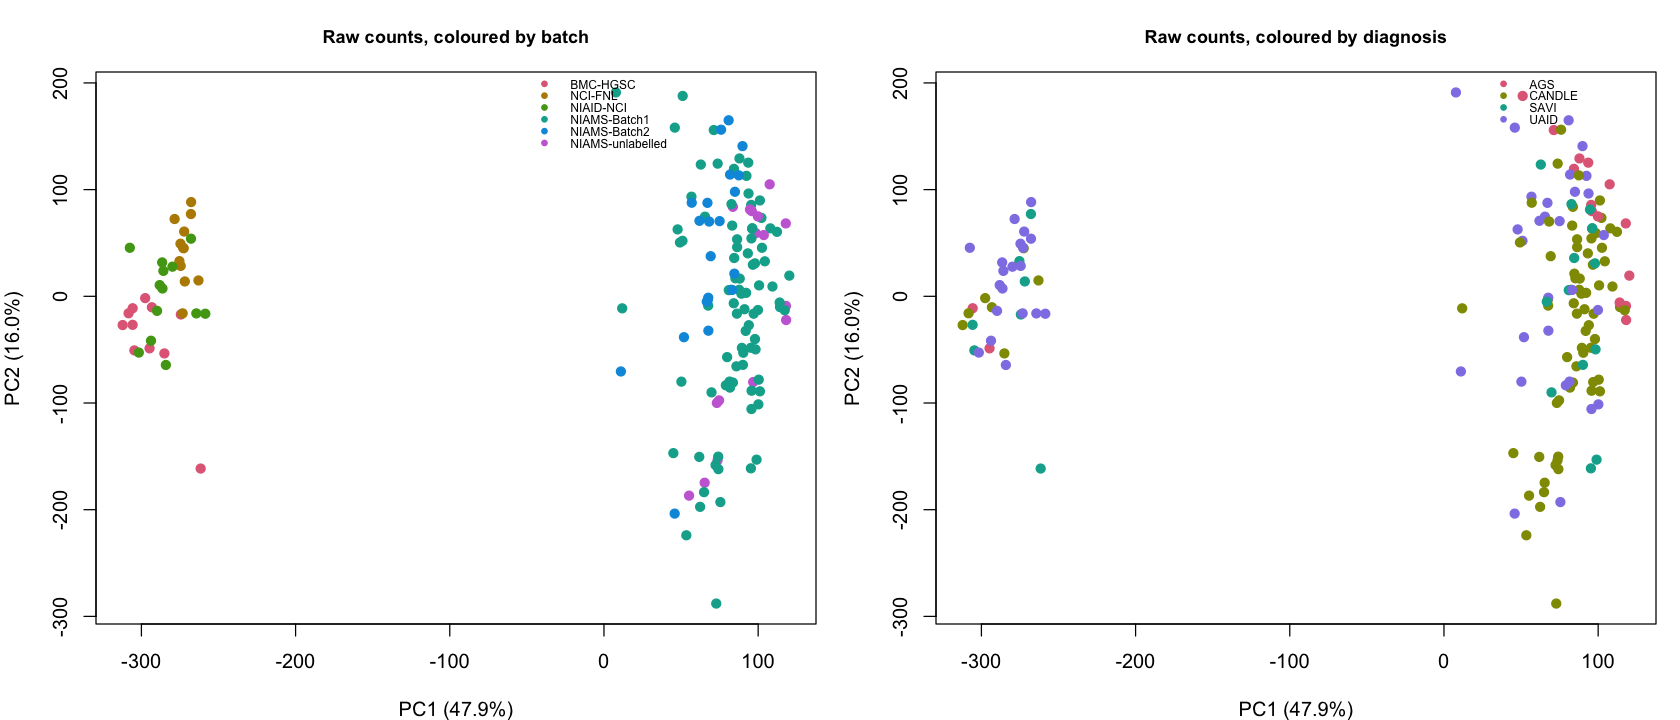

In [8]:
suppressMessages({library(edgeR); library(sva)})
expressed <- filterByExpr(DGEList(counts), group = info$diagnosis)
pca_plot <- function(M, title) {
  logcpm <- cpm(DGEList(M[expressed, ]), log = TRUE)
  p <- prcomp(t(logcpm))
  share <- round(100 * p$sdev^2 / sum(p$sdev^2), 1)
  par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
  for (by in c("batch", "diagnosis")) {
    f <- factor(info[[by]]); col <- setNames(hcl.colors(nlevels(f), "Dark 3"), levels(f))
    plot(p$x[, 1], p$x[, 2], col = col[as.character(f)], pch = 19,
         xlab = sprintf("PC1 (%.1f%%)", share[1]), ylab = sprintf("PC2 (%.1f%%)", share[2]),
         main = sprintf("%s, coloured by %s", title, by), cex.main = 0.9)
    legend("topright", legend = levels(f), col = col, pch = 19, cex = 0.6, bty = "n")
  }
  invisible(share)
}
c(genes = nrow(counts), expressed = sum(expressed))
options(repr.plot.width = 14, repr.plot.height = 6)
figure <- function() pca_plot(counts, "Raw counts")
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("CANDLE_SAVI", "40_pca_before.png"), width = 14, height = 6, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `library(edgeR)` (Robinson MD, McCarthy DJ, Smyth GK. *Bioinformatics* 2010;26:139-140) and `library(sva)`
  (Leek JT, Johnson WE, Parker HS, Jaffe AE, Storey JD. The sva package for removing batch effects and other
  unwanted variation in high-throughput experiments. *Bioinformatics* 2012;28:882-883) are loaded.
- `filterByExpr(DGEList(counts), group = info$diagnosis)` marks the genes with enough counts to be informative
  in at least as many samples as the smallest diagnosis group (Chen Y, Lun ATL, Smyth GK. From reads to genes
  to pathways. *F1000Research* 2016;5:1438). Only these genes are used for the PCA.
- `pca_plot(M, title)`:
  - `cpm(..., log = TRUE)` gives log2 counts per million, which removes differences in sequencing depth;
  - `prcomp(t(logcpm))` computes the principal components of the samples (Jolliffe IT. *Principal Component
    Analysis*, 2nd ed., Springer 2002); `share` is the percentage of variance of each component;
  - two panels, PC1 against PC2, coloured by batch and by diagnosis.
- The figure loop is explained in notebook 04.

**Result.** 26,636 of 57,789 genes pass `filterByExpr`. Before correction, PC1 (47.9% of the variance)
separates the three smaller facilities (BMC-HGSC, NCI-FNL, NIAID-NCI; median PC1 -273 to -298) from the three
NIAMS batches (median PC1 68 to 96): the samples group by facility, not by diagnosis.

## ComBat-seq

In [9]:
counts_cs <- ComBat_seq(counts, batch = info$batch, group = info$diagnosis)
dimnames(counts_cs) <- dimnames(counts)
c(genes = nrow(counts_cs), samples = ncol(counts_cs), negative = sum(counts_cs < 0), missing = sum(is.na(counts_cs)))

Found 6 batches
Using full model in ComBat-seq.
Adjusting for 3 covariate(s) or covariate level(s)
Estimating dispersions
Fitting the GLM model
Shrinkage off - using GLM estimates for parameters
Adjusting the data


genes  samples negative  missing 
   57789      160        0        0

**Explanation**
- `ComBat_seq(counts, batch, group)` fits a negative binomial model to each gene's counts, estimates how each
  batch shifts the gene's mean and spread, and returns adjusted counts, whole numbers, as if all samples had
  been sequenced in one batch (Zhang et al. 2020).
- `group = info$diagnosis` tells ComBat-seq the diagnosis of each sample, so that differences between
  diagnoses are kept, not removed as batch.
- The last line checks the size of the result and that no count is negative or missing.

**Result.** ComBat-seq returns 57,789 genes x 160 samples, with no negative or missing count.

## PCA after correction

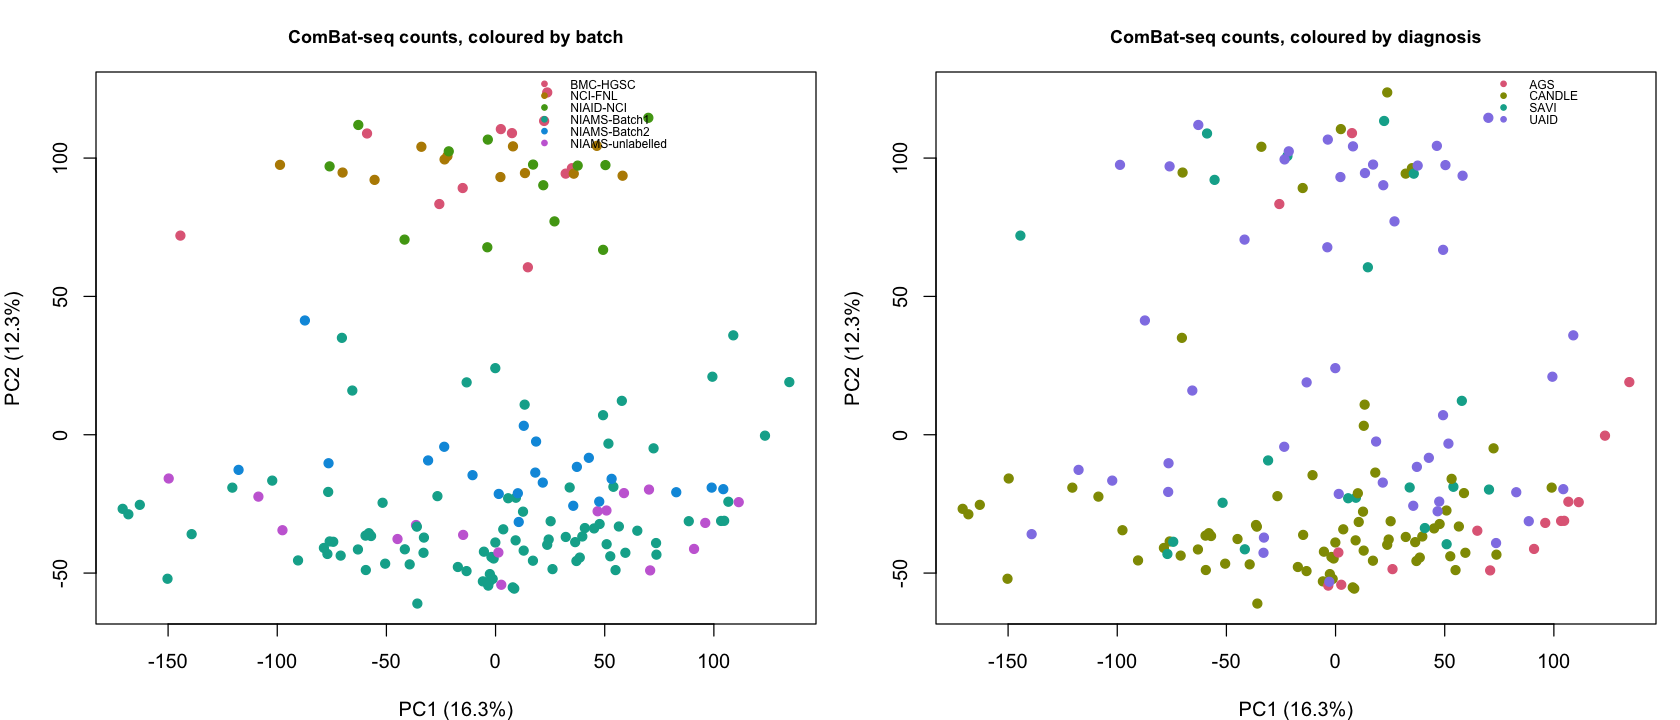

In [10]:
figure <- function() pca_plot(counts_cs, "ComBat-seq counts")
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("CANDLE_SAVI", "40_pca_after.png"), width = 14, height = 6, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- The same two panels as before correction, on the ComBat-seq counts.

**Result.** After correction the three smaller facilities and the NIAMS batches overlap on PC1 (16.3% of
the variance; median PC1 -10 to 25 in every batch). On PC2 (12.3%) the NIAMS batches (median PC2 -37 to -15)
still lie apart from the three smaller facilities (96 to 97).

## Save

In [11]:
samples <- info[, c("sample", "patient", "file", "batch", "diagnosis", "Treatment", "Sequencing_Facility", "Sequencing_Cohort", "Gender")]
saveRDS(list(counts = counts, genes = genes), art("CANDLE_SAVI", "counts_raw.rds"))
saveRDS(list(counts = counts_cs, genes = genes), art("CANDLE_SAVI", "counts_combatseq.rds"))
saveRDS(samples, art("CANDLE_SAVI", "samples.rds"))
saveRDS(key, art("CANDLE_SAVI", "sample_key.rds"))
dim(samples)

[1] 160   9

**Explanation**
- `samples` keeps, for each blood sample, the codes and labels used later: no enrollment ID, initials or
  date.
- `counts_raw.rds` (for differential expression) and `counts_combatseq.rds` (for display) hold the counts and
  the gene names; `samples.rds` the sample table; `sample_key.rds` the key, which stays in `data/` and is not
  committed.

**Result.** 160 samples saved, with codes and labels only.

## References

The methods, gene lists and software used in this notebook.

1. R Core Team. *R: A Language and Environment for Statistical Computing*. R Foundation for Statistical Computing, Vienna, Austria.
2. Robinson MD, McCarthy DJ, Smyth GK. edgeR: a Bioconductor package for differential expression analysis of digital gene expression data. *Bioinformatics* 2010;26:139-140.
3. Robinson MD, Oshlack A. A scaling normalization method for differential expression analysis of RNA-seq data. *Genome Biol* 2010;11:R25.
4. Chen Y, Lun ATL, Smyth GK. From reads to genes to pathways: differential expression analysis of RNA-Seq experiments using Rsubread and the edgeR quasi-likelihood pipeline. *F1000Research* 2016;5:1438.
5. Jolliffe IT. *Principal Component Analysis*, 2nd ed. Springer, New York 2002.
6. Zhang Y, Parmigiani G, Johnson WE. ComBat-seq: batch effect adjustment for RNA-seq count data. *NAR Genom Bioinform* 2020;2:lqaa078.
7. Leek JT, Johnson WE, Parker HS, Jaffe AE, Storey JD. The sva package for removing batch effects and other unwanted variation in high-throughput experiments. *Bioinformatics* 2012;28:882-883.
8. Love MI, Anders S, Kim V, Huber W. RNA-seq workflow: gene-level exploratory analysis and differential expression. *F1000Research* 2015;4:1070.
9. Conesa A, Madrigal P, Tarazona S, Gomez-Cabrero D, Cervera A, McPherson A, et al. A survey of best practices for RNA-seq data analysis. *Genome Biol* 2016;17:13.